# Tarea 15/4/26 - ADC / Cuantización

In [230]:
import numpy as np
import matplotlib.pyplot as plt

Vamos a simular el proceso de cuantización de una señal. Traemos el generador de senoidal ruidosa de la TS1 para generar nuestra señal muestreada de entrada:

In [231]:
def pds_awgn(N, fs, potencia_W):
    tt = np.arange(start = 0, step = 1/fs, stop = N*(1/fs))
    desvio_std = np.sqrt(potencia_W)
    media = 0
    xx = np.random.normal(loc=media, scale=desvio_std, size=N)
    return xx, tt

def pds_sen_ruidosa(nn = 1000, fs = 1000, freq = 1, Amax = np.sqrt(2), dc = 0, phase = 0, SNR_db = "inf"):
    tt = np.arange(start = 0, step = 1/fs, stop = nn*(1/fs))
    x1 = dc + Amax * np.sin(2*np.pi * freq * tt + phase)

    if SNR_db != "inf" and (type(SNR_db) == float or type(SNR_db) == int):
        pot_senal = 10*np.log10((Amax**2) / 2)
        pot_ruido = pot_senal - SNR_db
        x2, tt = pds_awgn(nn, fs, potencia_W = 10**(pot_ruido/10))
        xx = x1 + x2
    else:
        xx = x1

    return xx, tt

N = 50
fs = 50
f0 = 1
xx, tt = pds_sen_ruidosa(nn = N, fs = fs, freq = f0, Amax = np.sqrt(2), dc = 0, phase = 0, SNR_db = "inf")

##### Grafico de la señal muestreada en el tiempo (sin cuantizar)

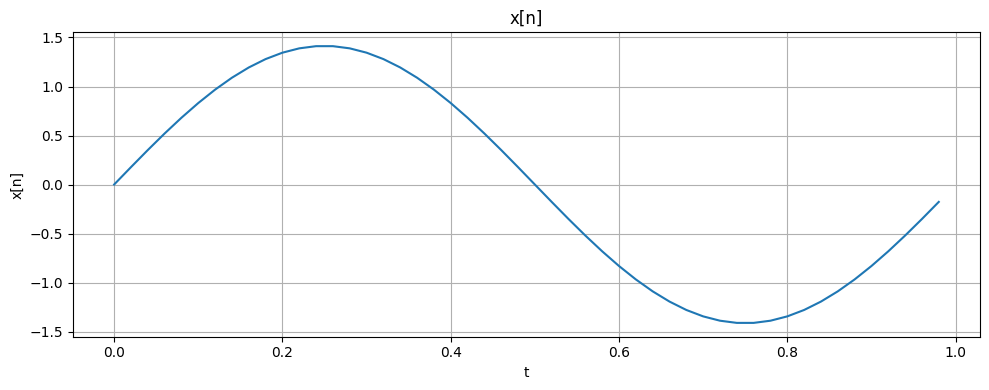

In [232]:
figure, axs = plt.subplots(1, 1, figsize=(10, 4))
axs.plot(tt, xx)
axs.set_xlabel('t')
axs.set_ylabel('x[n]')
axs.grid(True)
axs.set_title("x[n]")
#axs.set_xlim(0, 2)
plt.tight_layout()
plt.show()

El proceso de **cuantizacion** se encarga de mapear una señal continua a un número finito de niveles determinado por la resolución del ADC.

El **error de cuantización** es la diferencia entre el valor analógico original y su representación discreta, introducido por este proceso.

Definimos una resolución de 8 bits.

El rango del ADC debe cumplir $V_{FS} > 2 \cdot A_{MAX}$, y dado que $A_{MAX} = 1 \text{ V}$:

$$V_{FS} = 4 \text{ V} > 2\cdot\sqrt{2}\text{ V}$$


El paso de cuantización $q$ del ADC se define como el cociente entre el rango de entrada $V_{FS}$ y el número de niveles $2^B$, donde $B$ es la resolución en bits:

$$q = \frac{V_{FS}}{2^{B}}$$

In [233]:
BITS = 8
AMAX = 1
VFS = 4
q = VFS/(2**BITS)

print(f"Paso de cuantizacion q = {q * 1000:.2f} mV para 8 bits de cuantización y VFS = {VFS} V")

Paso de cuantizacion q = 15.62 mV para 8 bits de cuantización y VFS = 4 V


Para simular la cuantización dividimos y redondeamos por q, y volvemos a multiplicar por q para volver a obtener tensiones. Tambien "clipeamos" la señal entre +$V_{FS} / 2$ y -$V_{FS} / 2$

Graficamos para 4, 8 y 16 bits de cuantizacion.

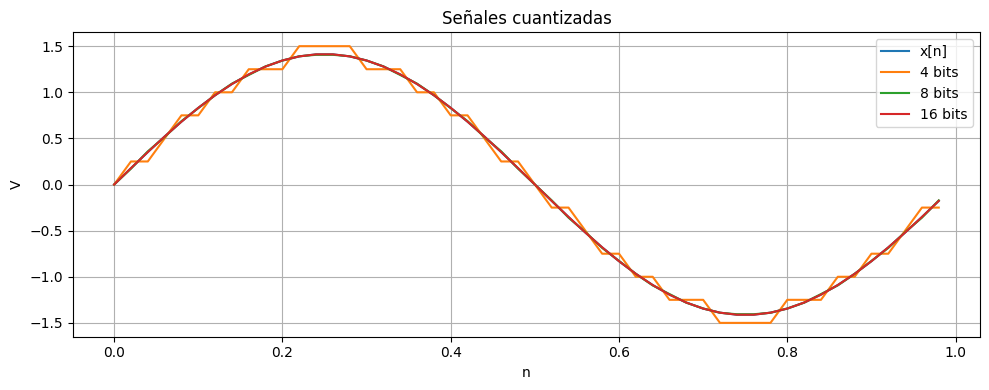

In [234]:
def pds_cuantizacion(xx, vfs, bits):
    xx_cuantizado = np.clip(xx, -vfs/2, vfs/2)
    q = vfs / (2 ** bits)
    xx_cuantizado = np.round(xx_cuantizado / q) * q
    return xx_cuantizado

xx_q1 = pds_cuantizacion(xx, VFS, 4)
xx_q2 = pds_cuantizacion(xx, VFS, 8)
xx_q3 = pds_cuantizacion(xx, VFS, 16)


figure, axs = plt.subplots(1, 1, figsize=(10, 4))

axs.plot(tt, xx, label = "x[n]")
axs.plot(tt, xx_q1, label = "4 bits")
axs.plot(tt, xx_q2, label = "8 bits")
axs.plot(tt, xx_q3, label = "16 bits")

axs.set_xlabel('n')
axs.set_ylabel('V')
#axs.set_xlim(0, (fs/f0) * 2)
axs.legend()
axs.grid(True)
axs.set_title("Señales cuantizadas")
plt.tight_layout()
plt.show()

A simple vista podemos vemos que para la señal original, 8 y 12 bits no notamos diferencias. Para 4 bits hay una diferencia notoria entre la señal original y la cuantizada.

El error de cuantización $e[n]$ se define como la diferencia entre la señal cuantizada $x_q[n]$ y la señal original $x[n]$:

$$e[n] = x_q[n] - x[n]$$

y se encuentra acotado por:

$$-\frac{q}{2} \leq e[n] < \frac{q}{2}$$

Podemos calcularlo y ver su distribución. Generamos una señal nueva que tenga mas ciclos, para que en el histograma se vean mas resultados.

Maximo error: 0.48*q
Minimo error: -0.48*q


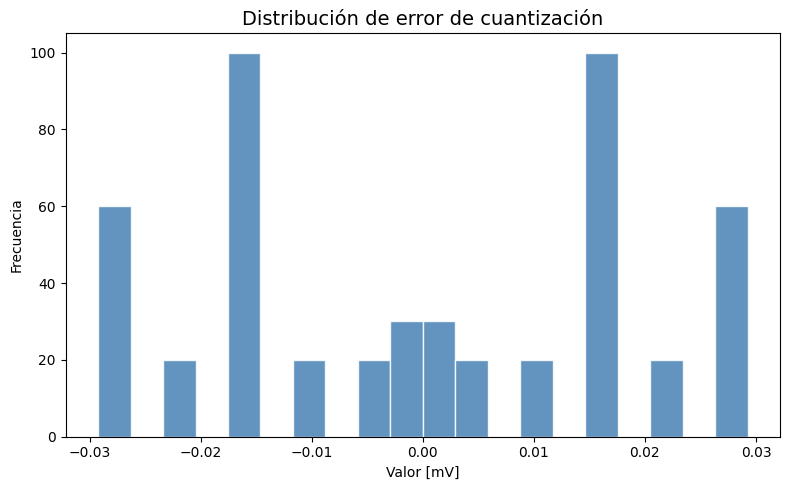

In [235]:
N = 500
fs = 50
f0 = 1
BITS_ADC = 16

xx, tt = pds_sen_ruidosa(nn = N, fs = fs, freq = f0, Amax = np.sqrt(2), dc = 0, phase = 0, SNR_db = "inf")
xx_q = pds_cuantizacion(xx, VFS, BITS_ADC)
eq = xx_q - xx
q = VFS/(2**BITS_ADC)

print(f"Maximo error: {(np.max(eq) / q):.2f}*q")
print(f"Minimo error: {(np.min(eq) / q):.2f}*q")

plt.figure(figsize=(8, 5))
plt.hist(eq*1000, bins=20, color='steelblue', edgecolor='white', alpha=0.85)

plt.title('Distribución de error de cuantización', fontsize=14)
plt.xlabel('Valor [mV]')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Vemos que la distribución no es una distribución uniforme como se esperaría. Para que el error de cuantización tenga distribución uniforme la señal de entrada debe ser una señal completamente incorrelacionada, obviamente no es nuestro caso con nuestra señal senoidal sin ruido.

Podemos comprobarlo:

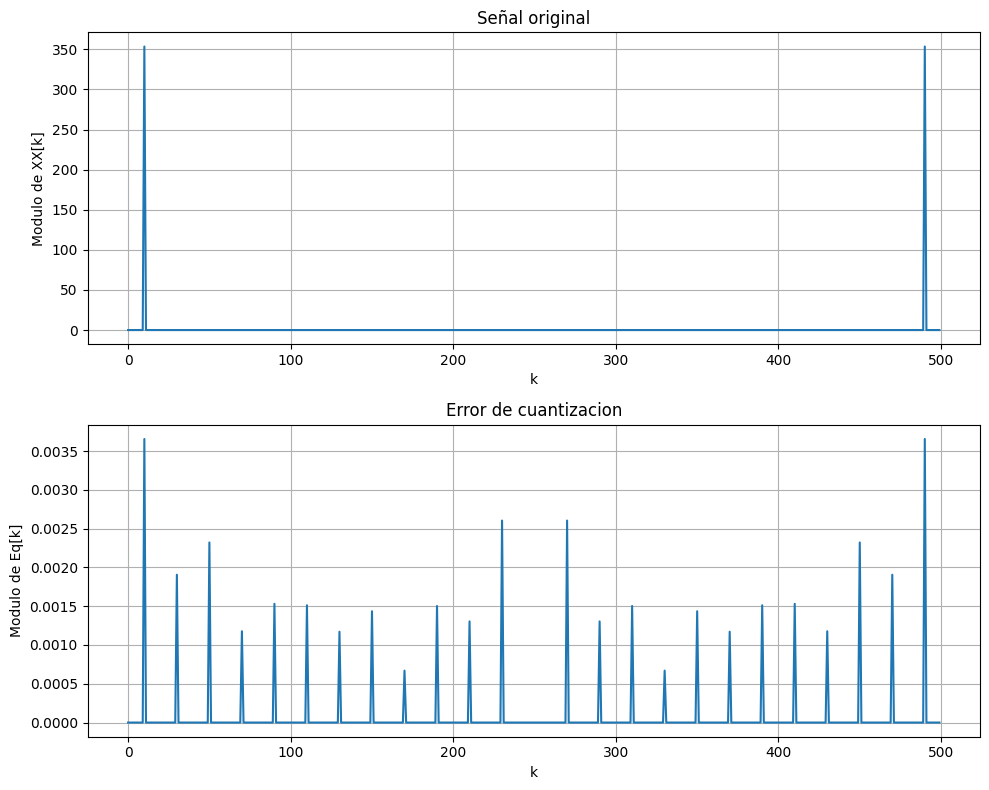

In [236]:
eq_fft = np.fft.fft(eq)

figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[1].plot(np.abs(eq_fft))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Modulo de Eq[k]')
axs[1].grid(True)
axs[1].set_title("Error de cuantizacion")

xx_fft = np.fft.fft(xx)
axs[0].plot(np.abs(xx_fft))
axs[0].set_xlabel('k')
axs[0].set_ylabel('Modulo de XX[k]')
axs[0].grid(True)
axs[0].set_title("Señal original")

plt.tight_layout()
plt.show()


Notamos que en las frecuencias donde tenemos señal tambien tenemos deltas en el error, demostrando que hay correlacion entre la señal de error y la señal cuantizada.


Podemos hacer que la señal sea "menos correlada" agregandole ruido AWGN a nuestra señal senoidal.

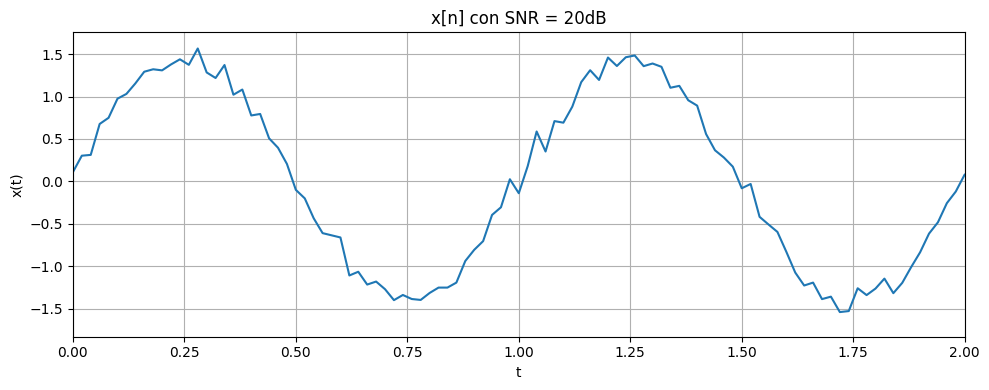

In [237]:
xx, tt = pds_sen_ruidosa(nn = N, fs = fs, freq = f0, Amax = np.sqrt(2), dc = 0, phase = 0, SNR_db = 20)
xx_q = pds_cuantizacion(xx, VFS, BITS_ADC)
eq = xx_q - xx


figure, axs = plt.subplots(1, 1, figsize=(10, 4))
axs.plot(tt, xx)
axs.set_xlabel('t')
axs.set_ylabel('x(t)')
axs.grid(True)
axs.set_title("x[n] con SNR = 20dB")
axs.set_xlim(0, 2)
plt.tight_layout()
plt.show()

Maximo error: 0.50*q
Minimo error: -0.50*q


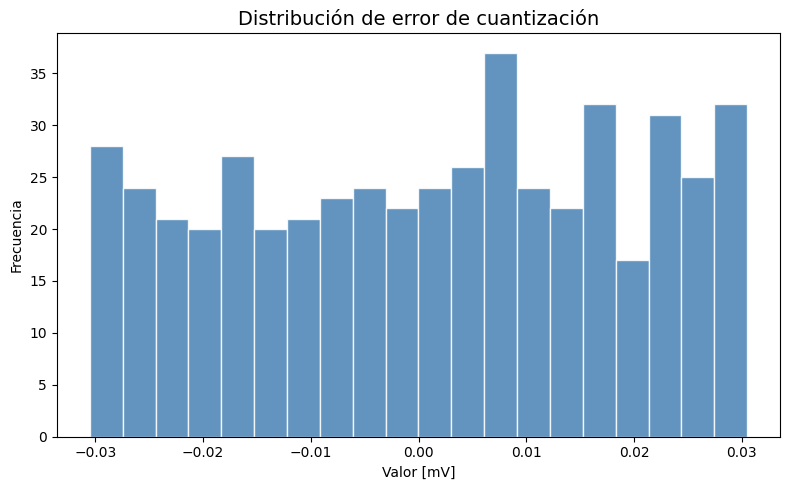

In [238]:
print(f"Maximo error: {(np.max(eq) / q):.2f}*q")
print(f"Minimo error: {(np.min(eq) / q):.2f}*q")

plt.figure(figsize=(8, 5))
plt.hist(eq*1000, bins=20, color='steelblue', edgecolor='white', alpha=0.85)

plt.title('Distribución de error de cuantización', fontsize=14)
plt.xlabel('Valor [mV]')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

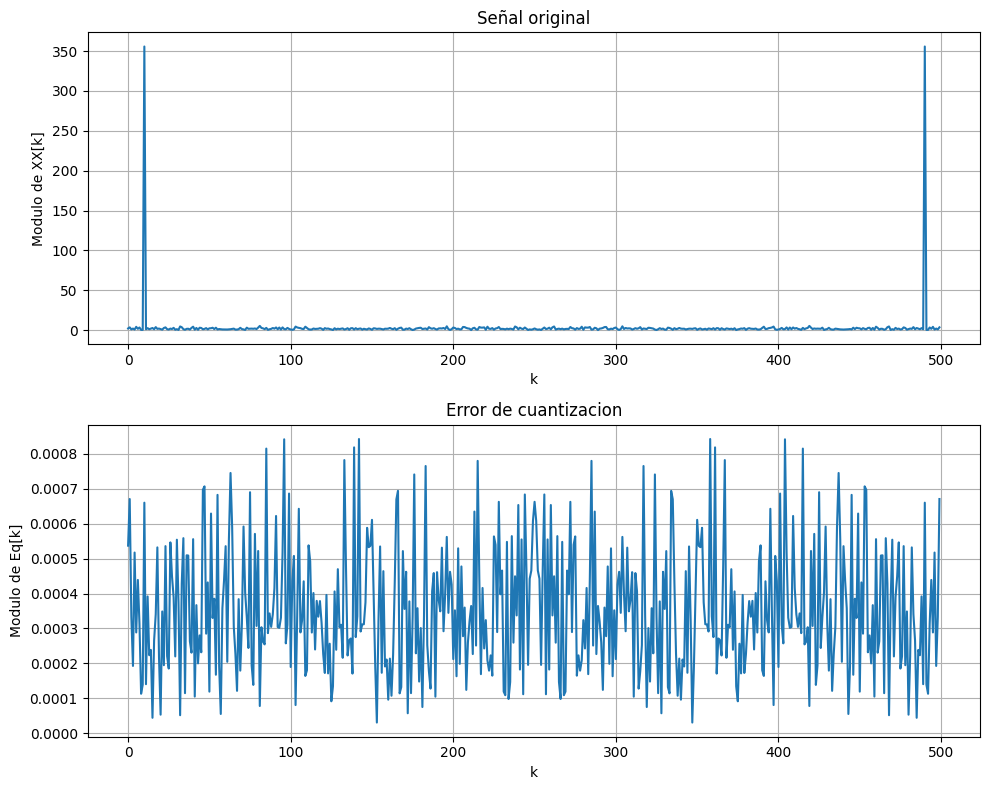

In [239]:
eq_fft = np.fft.fft(eq)

figure, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[1].plot(np.abs(eq_fft))
axs[1].set_xlabel('k')
axs[1].set_ylabel('Modulo de Eq[k]')
axs[1].grid(True)
axs[1].set_title("Error de cuantizacion")

xx_fft = np.fft.fft(xx)
axs[0].plot(np.abs(xx_fft))
axs[0].set_xlabel('k')
axs[0].set_ylabel('Modulo de XX[k]')
axs[0].grid(True)
axs[0].set_title("Señal original")

plt.tight_layout()
plt.show()

Vemos que el espectro de la señal comparado con el del ruido pierden similitudes, bajando en gran medida la correlacion entre estas señales.